In [13]:
import zipfile
import os
from pathlib import Path

ZIP_PATH = "/content/drive/MyDrive/MultiRes_ConfocFluo_HumanDentin.zip"
EXTRACT_PATH = "/content/dataset"

print("📦 Sadece ImagePatches128 açılıyor...")
print("⏳ Bu 5-10 dakika sürebilir, bekle...")

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    # Sadece ImagePatches128 içindeki dosyaları çıkar
    patches_dosyalar = [f for f in z.namelist()
                        if 'ImagePatches128' in f]

    toplam = len(patches_dosyalar)
    print(f"Açılacak dosya sayısı: {toplam:,}")

    for i, dosya in enumerate(patches_dosyalar):
        z.extract(dosya, EXTRACT_PATH)
        # Her 10000 dosyada bir ilerleme göster
        if i % 10000 == 0:
            print(f"  {i:,} / {toplam:,} ({i/toplam*100:.0f}%)")

print("\n✅ ImagePatches128 açıldı!")

# Kontrol
patches_root = Path(EXTRACT_PATH) / "MultiRes_ConfocFluo_HumanDentin" / "ImagePatches128" / "Classified"
print(f"\nKlasör var mı: {patches_root.exists()}")
for sinif in ["tubules", "branches", "both"]:
    klasor = patches_root / sinif / "HR"
    if klasor.exists():
        sayi = len(list(klasor.glob("*.tif")))
        print(f"  {sinif}/HR: {sayi} dosya")

📦 Sadece ImagePatches128 açılıyor...
⏳ Bu 5-10 dakika sürebilir, bekle...
Açılacak dosya sayısı: 361,873
  0 / 361,873 (0%)
  10,000 / 361,873 (3%)
  20,000 / 361,873 (6%)
  30,000 / 361,873 (8%)
  40,000 / 361,873 (11%)
  50,000 / 361,873 (14%)
  60,000 / 361,873 (17%)
  70,000 / 361,873 (19%)
  80,000 / 361,873 (22%)
  90,000 / 361,873 (25%)
  100,000 / 361,873 (28%)
  110,000 / 361,873 (30%)
  120,000 / 361,873 (33%)
  130,000 / 361,873 (36%)
  140,000 / 361,873 (39%)
  150,000 / 361,873 (41%)
  160,000 / 361,873 (44%)
  170,000 / 361,873 (47%)
  180,000 / 361,873 (50%)
  190,000 / 361,873 (53%)
  200,000 / 361,873 (55%)
  210,000 / 361,873 (58%)
  220,000 / 361,873 (61%)
  230,000 / 361,873 (64%)
  240,000 / 361,873 (66%)
  250,000 / 361,873 (69%)
  260,000 / 361,873 (72%)
  270,000 / 361,873 (75%)
  280,000 / 361,873 (77%)
  290,000 / 361,873 (80%)
  300,000 / 361,873 (83%)
  310,000 / 361,873 (86%)
  320,000 / 361,873 (88%)
  330,000 / 361,873 (91%)
  340,000 / 361,873 (94%)
  35

In [14]:
# ============================================================
# HÜCRE 2: ROI BAZLI SPLIT
# ============================================================
import torch
from pathlib import Path
from collections import Counter

PATCHES_ROOT = Path("/content/dataset/MultiRes_ConfocFluo_HumanDentin/ImagePatches128/Classified")
SINIFLAR      = ["tubules", "branches", "both"]
SINIF2IDX     = {s: i for i, s in enumerate(SINIFLAR)}
COZUNURLUKLER = ["HR", "x2", "x4", "x8"]
CLASS_WEIGHTS = torch.tensor([2.3807, 0.3868, 0.2325], dtype=torch.float)

TRAIN_ROIS = ["roi01", "roi02", "roi03", "roi04"]
VAL_ROIS   = ["roi05"]
TEST_ROIS  = ["roi06"]

def get_roi(filename):
    for p in Path(filename).stem.split('_'):
        if p.startswith('roi'):
            return p
    return None

def build_file_list(patches_root, siniflar, cozunurluk, roi_listesi):
    dosyalar = []
    for sinif in siniflar:
        klasor = patches_root / sinif / cozunurluk
        if not klasor.exists():
            continue
        for tif in sorted(klasor.glob("*.tif")):
            roi = get_roi(tif.name)
            if roi in roi_listesi:
                dosyalar.append((str(tif), SINIF2IDX[sinif]))
    return dosyalar

print("="*50)
print("ROI BAZLI SPLIT — HR Çözünürlük")
print("="*50)
idx2sinif = {v: k for k, v in SINIF2IDX.items()}

for split_adi, roi_listesi in [("Train", TRAIN_ROIS),
                                ("Val",   VAL_ROIS),
                                ("Test",  TEST_ROIS)]:
    dosyalar = build_file_list(PATCHES_ROOT, SINIFLAR, "HR", roi_listesi)
    dagilim  = Counter(e for _, e in dosyalar)
    print(f"\n{split_adi} ({roi_listesi}): {len(dosyalar):,} patch")
    for idx in range(3):
        sayi = dagilim[idx]
        oran = sayi / len(dosyalar) * 100 if dosyalar else 0
        print(f"  {idx2sinif[idx]:<12}: {sayi:>6,}  (%{oran:.1f})")

print("\n✅ Split hazır!")

ROI BAZLI SPLIT — HR Çözünürlük

Train (['roi01', 'roi02', 'roi03', 'roi04']): 60,125 patch
  tubules     :  3,486  (%5.8)
  branches    : 21,911  (%36.4)
  both        : 34,728  (%57.8)

Val (['roi05']): 13,393 patch
  tubules     :    434  (%3.2)
  branches    :  6,606  (%49.3)
  both        :  6,353  (%47.4)

Test (['roi06']): 16,946 patch
  tubules     :  1,281  (%7.6)
  branches    :  3,493  (%20.6)
  both        : 12,172  (%71.8)

✅ Split hazır!


In [15]:
# ============================================================
# HÜCRE 3: PYTORCH DATASET + DATALOADER
# ============================================================
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import tifffile
from PIL import Image

class DentinDataset(Dataset):
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, dosya_listesi, augmentation=False):
        self.dosya_listesi = dosya_listesi
        self.augmentation  = augmentation
        self.train_tf = transforms.Compose([
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomVerticalFlip(0.5),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(self.MEAN, self.STD)
        ])
        self.val_tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(self.MEAN, self.STD)
        ])

    def __len__(self):
        return len(self.dosya_listesi)

    def __getitem__(self, idx):
        yol, etiket = self.dosya_listesi[idx]
        img = Image.fromarray(tifffile.imread(yol)).convert("RGB")
        tf  = self.train_tf if self.augmentation else self.val_tf
        return tf(img), torch.tensor(etiket, dtype=torch.long)

# Dataset'leri oluştur
BATCH_SIZE = 64

train_d = DentinDataset(build_file_list(PATCHES_ROOT, SINIFLAR, "HR", TRAIN_ROIS), augmentation=True)
val_d   = DentinDataset(build_file_list(PATCHES_ROOT, SINIFLAR, "HR", VAL_ROIS),   augmentation=False)
test_d  = DentinDataset(build_file_list(PATCHES_ROOT, SINIFLAR, "HR", TEST_ROIS),  augmentation=False)

train_loader = DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_d,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_d,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Train : {len(train_d):,} patch → {len(train_loader)} batch")
print(f"✅ Val   : {len(val_d):,} patch → {len(val_loader)} batch")
print(f"✅ Test  : {len(test_d):,} patch → {len(test_loader)} batch")

✅ Train : 60,125 patch → 940 batch
✅ Val   : 13,393 patch → 210 batch
✅ Test  : 16,946 patch → 265 batch


Batch şekli : torch.Size([64, 3, 128, 128])
Etiketler   : [1, 2, 1, 2, 2, 2, 1, 1]


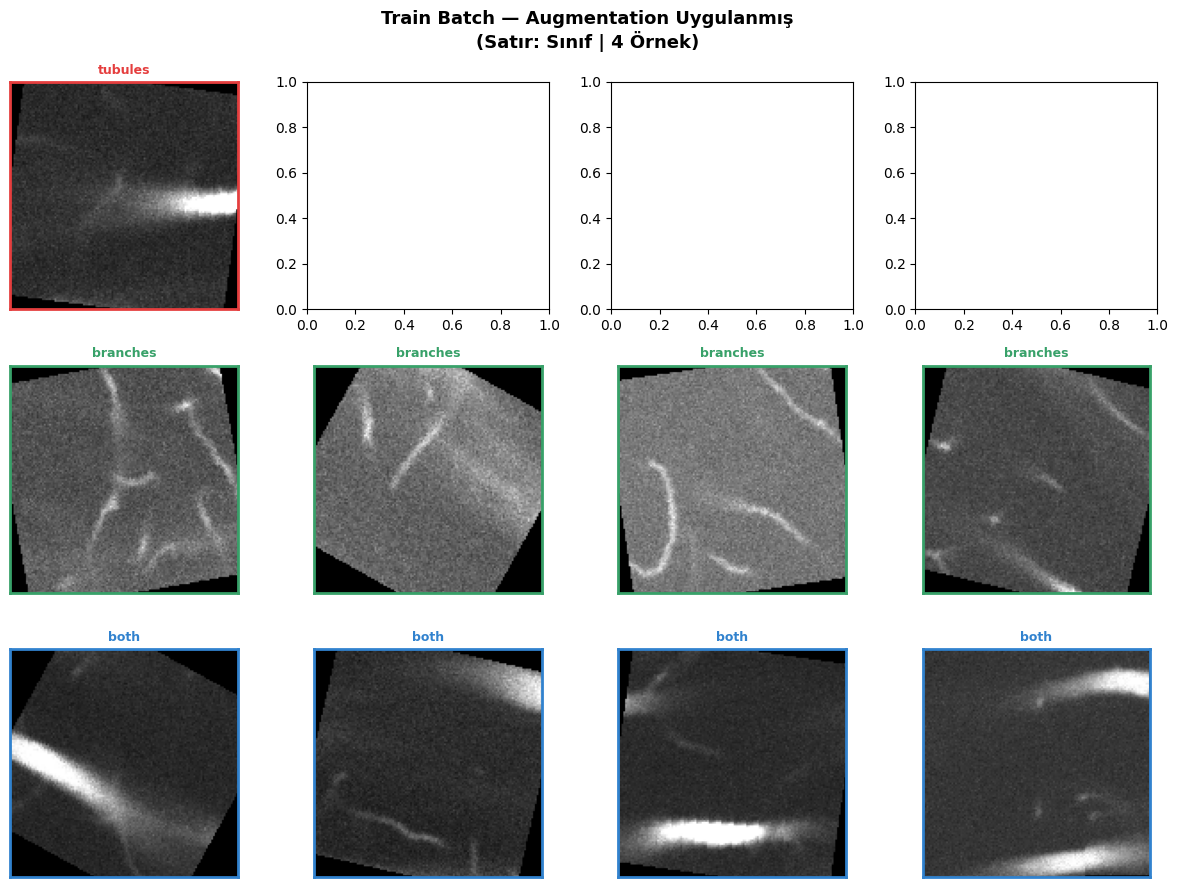

✅ Notebook 02 tamamlandı — Model eğitimine hazırız!


In [16]:
# ============================================================
# HÜCRE 4: KONTROL — BİR BATCH GÖRSELLEŞTİR
# ============================================================
import matplotlib.pyplot as plt

def denormalize(t):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return torch.clamp(t * std + mean, 0, 1)

ornekler, etiketler = next(iter(train_loader))
print(f"Batch şekli : {ornekler.shape}")
print(f"Etiketler   : {etiketler[:8].tolist()}")

renkler  = {0:"#E53E3E", 1:"#38A169", 2:"#3182CE"}
ad       = {0:"tubules", 1:"branches", 2:"both"}

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle("Train Batch — Augmentation Uygulanmış\n(Satır: Sınıf | 4 Örnek)",
             fontsize=13, fontweight='bold')

gosterilen = {0:0, 1:0, 2:0}
for i in range(len(ornekler)):
    e = etiketler[i].item()
    if gosterilen[e] < 4:
        ax = axes[e][gosterilen[e]]
        img = denormalize(ornekler[i]).permute(1,2,0).numpy()[:,:,0]
        ax.imshow(img, cmap='gray')
        ax.set_title(ad[e], fontsize=9, color=renkler[e], fontweight='bold')
        for sp in ax.spines.values():
            sp.set_edgecolor(renkler[e]); sp.set_linewidth(2)
        ax.set_xticks([]); ax.set_yticks([])
        gosterilen[e] += 1
        if all(v >= 4 for v in gosterilen.values()):
            break

plt.tight_layout()
plt.savefig("batch_ornegi.png", dpi=130, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Notebook 02 tamamlandı — Model eğitimine hazırız!")